# Classificação de Moscas com Redes Neurais

**Disciplina:** SCC0270 - Redes Neurais e Aprendizado Profundo  
**Tema escolhido:** Redes Neurais Convolucionais, com baseline em MLP para comparação  
**Problema:** classificar recortes de insetos em duas classes:

- `WF`: mosca-branca (*Bemisia tabaci*)
- `MR`: outros insetos presentes nas armadilhas

## Objetivos deste notebook

1. montar o conjunto de dados a partir das pastas `WF` e `MR`;
2. realizar análise exploratória simples;
3. dividir os dados em treino, validação e teste de forma estratificada;
4. treinar dois modelos neurais:
   - um **MLP** como baseline;
   - uma **CNN** como modelo principal do projeto;
5. avaliar os modelos com foco em **Área sob a Curva Precisão-Revocação (Average Precision / PR-AUC)**.

## Justificativa dos tópicos escolhidos

- **CNNs** foram escolhidas como tema principal porque imagens têm estrutura espacial, e convoluções exploram padrões locais como contornos, textura e formato com muito menos parâmetros do que uma rede totalmente conectada.
- **MLP / Perceptron multicamadas** foi usado como baseline por ser um tópico clássico da disciplina e servir como comparação direta. Assim fica claro por que modelos com viés espacial são mais apropriados para visão computacional.
- **Transferência de aprendizado** foi considerada, mas não adotada como solução principal porque este problema já alcança desempenho muito alto com modelos menores e mais baratos computacionalmente.


## Observação de reprodutibilidade

Este notebook foi preparado para rodar tanto localmente quanto no Google Colab.  
Se você usar o Colab, basta ajustar a variável `DATA_DIR` para apontar para a pasta
`EMBRAPA-dataset-WF`.


In [1]:
from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


/home/fersuaiden/.local/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.1)
  from scipy.stats import gaussian_kde


Device: cpu


In [2]:
# Ajuste este caminho se for rodar no Colab.
DATA_DIR = Path("EMBRAPA-dataset-WF-20260531T201814Z-3-001/EMBRAPA-dataset-WF")

assert DATA_DIR.exists(), f"Pasta nao encontrada: {DATA_DIR}"
assert (DATA_DIR / "WF").exists(), "Pasta WF nao encontrada"
assert (DATA_DIR / "MR").exists(), "Pasta MR nao encontrada"

DATA_DIR


PosixPath('EMBRAPA-dataset-WF-20260531T201814Z-3-001/EMBRAPA-dataset-WF')

## 1. Montagem dos dados

O enunciado pede que o treinamento seja feito com os recortes já prontos nas pastas `WF` e `MR`.
Cada arquivo `.jpg` vira uma amostra, e o rótulo é:

- `1` para `WF`
- `0` para `MR`


In [3]:
def build_dataframe(data_dir: Path) -> pd.DataFrame:
    rows = []
    for class_name, label in [("WF", 1), ("MR", 0)]:
        class_dir = data_dir / class_name
        for image_path in sorted(class_dir.glob("*.jpg")):
            rows.append(
                {
                    "path": str(image_path),
                    "class_name": class_name,
                    "label": label,
                }
            )
    return pd.DataFrame(rows)


df = build_dataframe(DATA_DIR)
df.head()


,path,class_name,label
0,EMBRAPA-dataset-WF-20260531T201814Z-3-001/EMBR...,WF,1
1,EMBRAPA-dataset-WF-20260531T201814Z-3-001/EMBR...,WF,1
2,EMBRAPA-dataset-WF-20260531T201814Z-3-001/EMBR...,WF,1
3,EMBRAPA-dataset-WF-20260531T201814Z-3-001/EMBR...,WF,1
4,EMBRAPA-dataset-WF-20260531T201814Z-3-001/EMBR...,WF,1


In [4]:
class_counts = df["class_name"].value_counts().rename_axis("classe").reset_index(name="quantidade")
class_counts


,classe,quantidade
0,WF,6350
1,MR,1287


O conjunto é desbalanceado: existem muito mais recortes da classe `WF` do que da classe `MR`.
Por isso, durante o treino vamos usar **amostragem ponderada** para reduzir o viés da classe majoritária.


In [5]:
def collect_image_stats(frame: pd.DataFrame) -> pd.DataFrame:
    stats = []
    for _, row in frame.iterrows():
        with Image.open(row["path"]) as img:
            width, height = img.size
        stats.append(
            {
                "path": row["path"],
                "class_name": row["class_name"],
                "label": row["label"],
                "width": width,
                "height": height,
                "area": width * height,
            }
        )
    return pd.DataFrame(stats)


stats_df = collect_image_stats(df)
stats_df.groupby("class_name")[["width", "height", "area"]].describe().round(2)


width                                                   height  \
             count    mean    std   min    25%    50%    75%    max   count   
class_name                                                                    
MR          1287.0  138.44  35.12  27.0  114.0  138.0  162.0  271.0  1287.0   
WF          6350.0   56.24  14.81  20.0   46.0   56.0   66.0  147.0  6350.0   

                    ...                  area                             \
              mean  ...    75%    max   count      mean      std     min   
class_name          ...                                                    
MR          123.39  ...  145.0  247.0  1287.0  17169.83  6403.16  1080.0   
WF           50.64  ...   58.0  149.0  6350.0   2963.44  1392.51   400.0   

                                                
                25%      50%      75%      max  
class_name                                      
MR          12507.5  16789.0  21365.0  41420.0  
WF           1978.0   2754.0   3672.0  19966.0  

[2 rows x 24 columns]

## 2. Análise exploratória

A análise exploratória mostra algo importante para interpretar os resultados:

- os recortes `WF` tendem a ser menores;
- os recortes `MR` costumam ser maiores;
- portanto, o tamanho do objeto já carrega informação discriminativa.

Isso explica por que até modelos relativamente simples podem atingir resultados fortes.


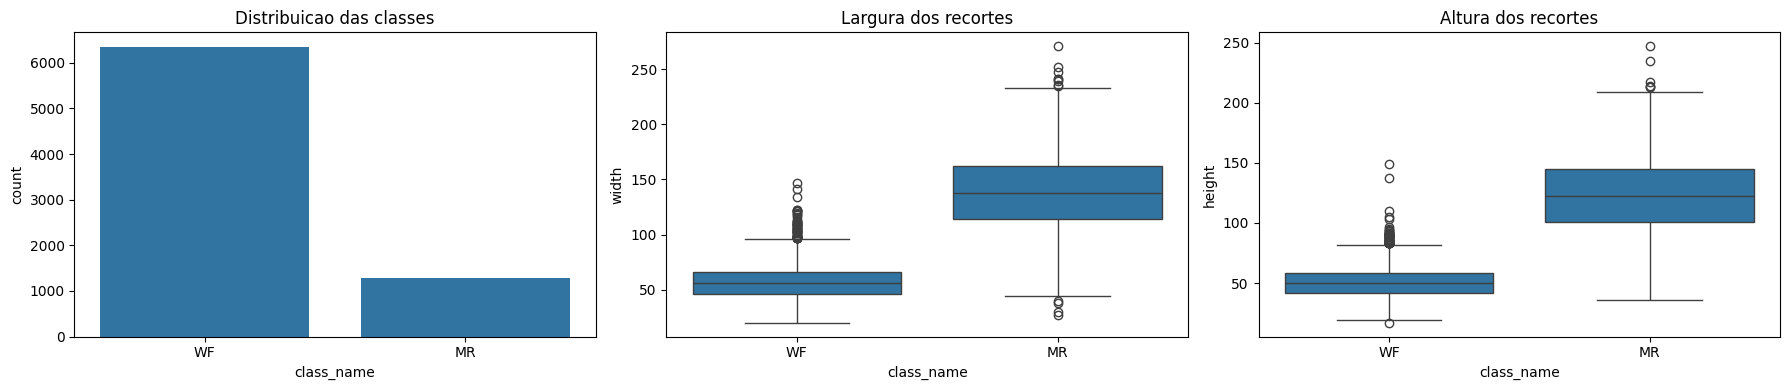

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

sns.countplot(data=df, x="class_name", ax=axes[0])
axes[0].set_title("Distribuicao das classes")

sns.boxplot(data=stats_df, x="class_name", y="width", ax=axes[1])
axes[1].set_title("Largura dos recortes")

sns.boxplot(data=stats_df, x="class_name", y="height", ax=axes[2])
axes[2].set_title("Altura dos recortes")

plt.tight_layout()
plt.show()


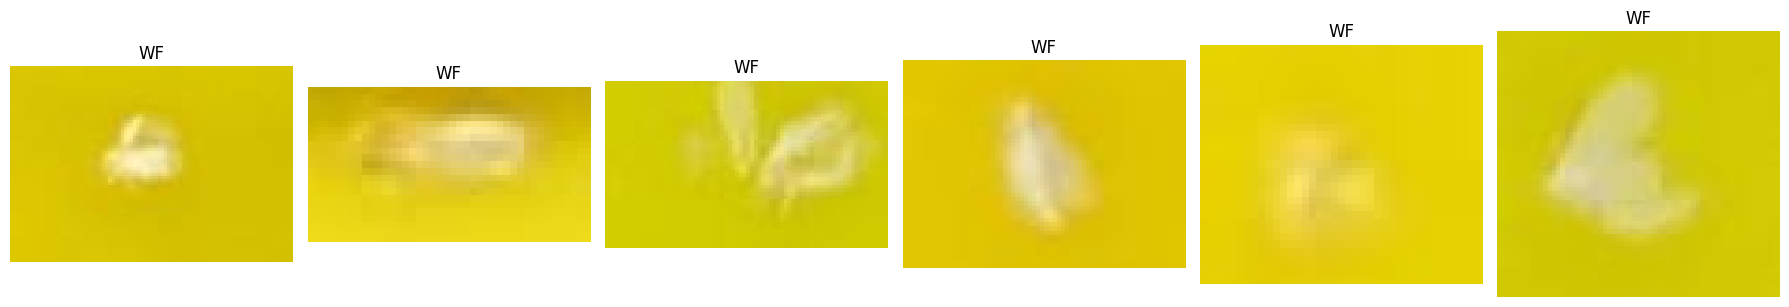

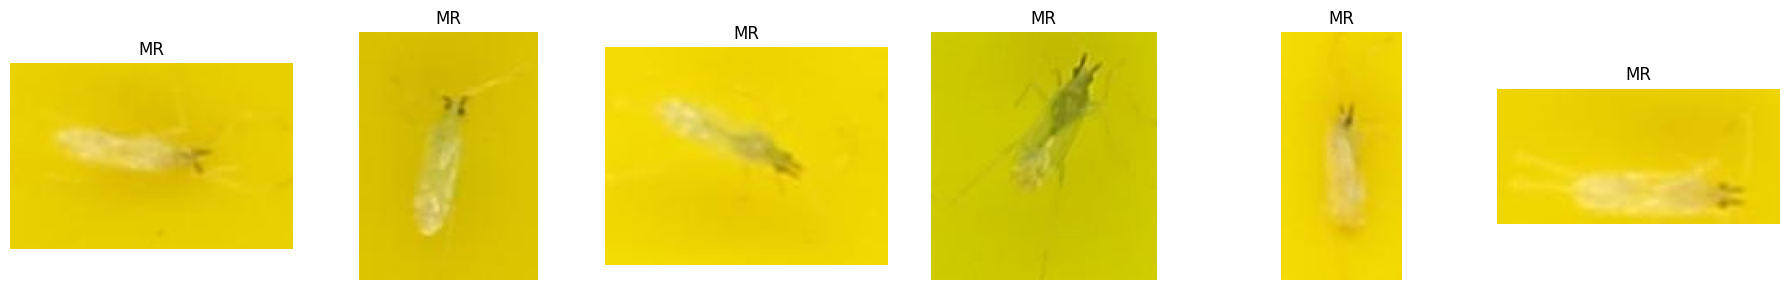

In [7]:
def show_examples(frame: pd.DataFrame, class_name: str, n: int = 6):
    subset = frame[frame["class_name"] == class_name].sample(n, random_state=RANDOM_SEED)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    for ax, (_, row) in zip(axes, subset.iterrows()):
        with Image.open(row["path"]) as img:
            ax.imshow(img)
        ax.set_title(class_name)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


show_examples(df, "WF")
show_examples(df, "MR")


## 3. Divisão treino/validação/teste

Foi usada uma divisão estratificada em:

- `70%` treino
- `15%` validação
- `15%` teste

A estratificação preserva a proporção entre as classes em todas as partições.


In [8]:
indices = np.arange(len(df))
labels = df["label"].to_numpy()

train_idx, test_idx = train_test_split(
    indices,
    test_size=0.15,
    stratify=labels,
    random_state=RANDOM_SEED,
)

train_idx, val_idx = train_test_split(
    train_idx,
    test_size=0.1764705882,  # produz 15% do total para validacao
    stratify=labels[train_idx],
    random_state=RANDOM_SEED,
)


def split_summary(name: str, idx: np.ndarray) -> dict:
    split_labels = labels[idx]
    return {
        "split": name,
        "total": len(idx),
        "WF": int((split_labels == 1).sum()),
        "MR": int((split_labels == 0).sum()),
    }


split_table = pd.DataFrame(
    [
        split_summary("Treino", train_idx),
        split_summary("Validacao", val_idx),
        split_summary("Teste", test_idx),
    ]
)
split_table


,split,total,WF,MR
0,Treino,5345,4444,901
1,Validacao,1146,953,193
2,Teste,1146,953,193


## 4. Pré-processamento

As imagens possuem tamanhos variados. Para permitir processamento em lotes,
os recortes são redimensionados para um tamanho fixo.

Estratégias adotadas:

- **MLP**: imagens em `32x32` para manter o número de parâmetros sob controle;
- **CNN**: imagens em `64x64`, pois a convolução aproveita melhor a resolução extra;
- **Data augmentation** no treino da CNN:
  - rotação pequena;
  - espelhamento horizontal.

Não foi aplicada padronização mais agressiva porque os modelos já convergem bem com `ToTensor()`,
que coloca os pixels em `[0, 1]`.


In [9]:
class FlyDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, indices, transform, flatten: bool = False):
        self.frame = frame.reset_index(drop=True)
        self.indices = list(indices)
        self.transform = transform
        self.flatten = flatten

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        row = self.frame.iloc[self.indices[idx]]
        with Image.open(row["path"]).convert("RGB") as img:
            x = self.transform(img)
        if self.flatten:
            x = torch.flatten(x)
        y = torch.tensor(row["label"], dtype=torch.float32)
        return x, y


mlp_train_tfms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

cnn_train_tfms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])

eval_mlp_tfms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
])

eval_cnn_tfms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])


## 5. DataLoaders e amostragem balanceada

Como `MR` é minoria, usamos `WeightedRandomSampler` no treino.
Isso faz com que a rede veja exemplos das duas classes com frequência mais equilibrada.


In [10]:
def make_weighted_sampler(train_labels: np.ndarray) -> WeightedRandomSampler:
    class_counts = np.bincount(train_labels.astype(int))
    sample_weights = np.array([1.0 / class_counts[label] for label in train_labels], dtype=np.float64)
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)


train_labels = labels[train_idx]
sampler = make_weighted_sampler(train_labels)

mlp_train_ds = FlyDataset(df, train_idx, mlp_train_tfms, flatten=True)
mlp_val_ds = FlyDataset(df, val_idx, eval_mlp_tfms, flatten=True)
mlp_test_ds = FlyDataset(df, test_idx, eval_mlp_tfms, flatten=True)

cnn_train_ds = FlyDataset(df, train_idx, cnn_train_tfms, flatten=False)
cnn_val_ds = FlyDataset(df, val_idx, eval_cnn_tfms, flatten=False)
cnn_test_ds = FlyDataset(df, test_idx, eval_cnn_tfms, flatten=False)

mlp_train_loader = DataLoader(mlp_train_ds, batch_size=128, sampler=sampler)
mlp_val_loader = DataLoader(mlp_val_ds, batch_size=256, shuffle=False)
mlp_test_loader = DataLoader(mlp_test_ds, batch_size=256, shuffle=False)

cnn_train_loader = DataLoader(cnn_train_ds, batch_size=128, sampler=sampler)
cnn_val_loader = DataLoader(cnn_val_ds, batch_size=256, shuffle=False)
cnn_test_loader = DataLoader(cnn_test_ds, batch_size=256, shuffle=False)


## 6. Modelos neurais

### Baseline: MLP

O MLP recebe a imagem achatada em um único vetor. Isso elimina a estrutura espacial,
mas serve como referência de desempenho.

### Modelo principal: CNN

A CNN usa convoluções e *pooling* para extrair padrões locais e reduzir dimensionalidade
gradualmente. Esse é o modelo mais coerente com o tema do projeto.


In [11]:
class MLPClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(32 * 32 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


class CNNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


mlp_model = MLPClassifier()
cnn_model = CNNClassifier()

print("Parametros MLP:", count_params(mlp_model))
print("Parametros CNN:", count_params(cnn_model))


Parametros MLP: 803201
Parametros CNN: 23649


Mesmo sendo mais apropriada para imagens, a CNN usa muito menos parâmetros do que o MLP definido aqui.
Isso é um ponto importante da justificativa metodológica.


In [12]:
def evaluate_model(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_items = 0
    y_true = []
    y_prob = []

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            probs = torch.sigmoid(logits)

            total_loss += loss.item() * len(y_batch)
            total_items += len(y_batch)
            y_true.extend(y_batch.cpu().numpy().tolist())
            y_prob.extend(probs.cpu().numpy().tolist())

    avg_loss = total_loss / total_items
    ap = average_precision_score(y_true, y_prob)
    return avg_loss, ap, np.array(y_true), np.array(y_prob)


def train_model(model, train_loader, val_loader, epochs=4, lr=1e-3):
    model = model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    best_state = None
    best_val_ap = -np.inf

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        running_items = 0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(y_batch)
            running_items += len(y_batch)

        train_loss = running_loss / running_items
        val_loss, val_ap, _, _ = evaluate_model(model, val_loader, criterion)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_ap": val_ap,
            }
        )
        print(
            f"epoch={epoch} train_loss={train_loss:.4f} "
            f"val_loss={val_loss:.4f} val_ap={val_ap:.4f}"
        )

        if val_ap > best_val_ap:
            best_val_ap = val_ap
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history)


def plot_history(history_df: pd.DataFrame, title: str):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="treino")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="validacao")
    axes[0].set_title(f"Loss - {title}")
    axes[0].legend()

    axes[1].plot(history_df["epoch"], history_df["val_ap"], marker="o", color="darkgreen")
    axes[1].set_title(f"AP de validacao - {title}")
    axes[1].set_ylim(0.0, 1.05)

    plt.tight_layout()
    plt.show()


def plot_pr_curve(y_true, y_prob, title: str):
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    ap = average_precision_score(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Revocacao")
    plt.ylabel("Precisao")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def show_confusion_matrix(y_true, y_prob, title: str, threshold: float = 0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()
    print(classification_report(y_true, y_pred, target_names=["MR", "WF"], digits=4))


## 7. Experimento 1: baseline com MLP

Este experimento mostra até onde uma rede densa chega quando recebe apenas pixels achatados.


epoch=1 train_loss=0.5208 val_loss=0.2548 val_ap=0.9890
epoch=2 train_loss=0.2766 val_loss=0.2851 val_ap=0.9935
epoch=3 train_loss=0.2521 val_loss=0.1848 val_ap=0.9943
epoch=4 train_loss=0.2296 val_loss=0.1724 val_ap=0.9948


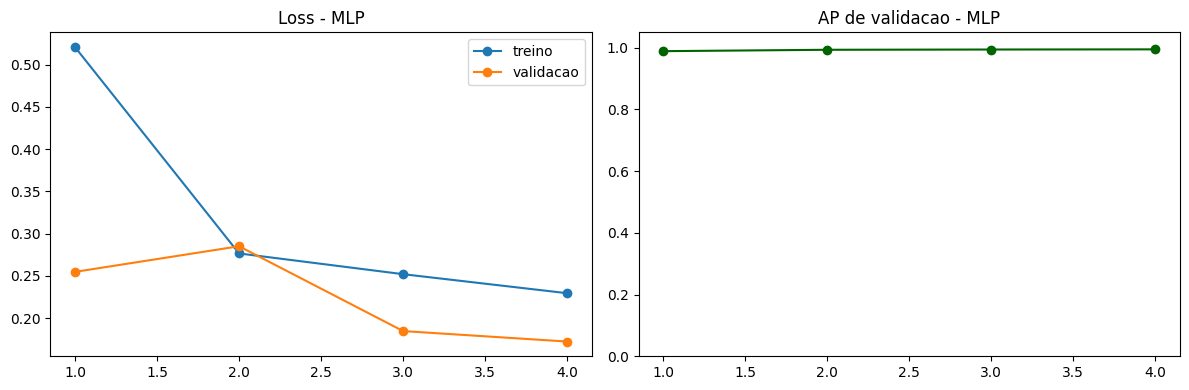

In [13]:
mlp_model = MLPClassifier()
mlp_model, mlp_history = train_model(
    mlp_model,
    mlp_train_loader,
    mlp_val_loader,
    epochs=4,
    lr=1e-3,
)

plot_history(mlp_history, "MLP")


In [14]:
criterion = nn.BCEWithLogitsLoss()
mlp_test_loss, mlp_test_ap, mlp_y_true, mlp_y_prob = evaluate_model(
    mlp_model,
    mlp_test_loader,
    criterion,
)

print(f"MLP - test_loss = {mlp_test_loss:.4f}")
print(f"MLP - test_AP   = {mlp_test_ap:.4f}")


MLP - test_loss = 0.1657
MLP - test_AP   = 0.9953


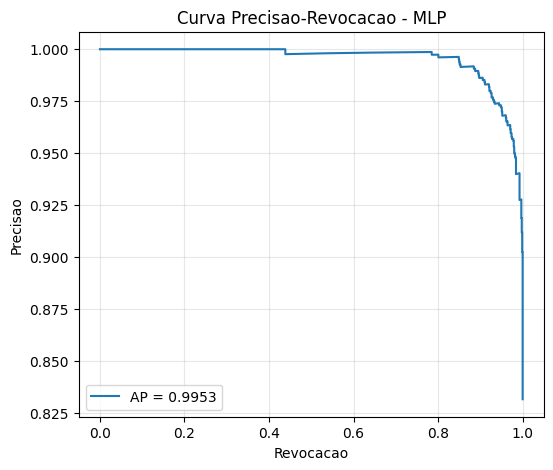

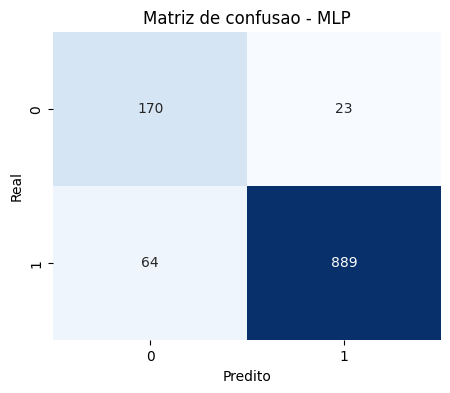

              precision    recall  f1-score   support

          MR     0.7265    0.8808    0.7963       193
          WF     0.9748    0.9328    0.9534       953

    accuracy                         0.9241      1146
   macro avg     0.8506    0.9068    0.8748      1146
weighted avg     0.9330    0.9241    0.9269      1146



In [15]:
plot_pr_curve(mlp_y_true, mlp_y_prob, "Curva Precisao-Revocacao - MLP")
show_confusion_matrix(mlp_y_true, mlp_y_prob, "Matriz de confusao - MLP")


## 8. Experimento 2: CNN como modelo principal

Agora treinamos a arquitetura escolhida para a entrega principal.


epoch=1 train_loss=0.6512 val_loss=0.5245 val_ap=0.9702
epoch=2 train_loss=0.4113 val_loss=0.4669 val_ap=0.9856
epoch=3 train_loss=0.3094 val_loss=0.2426 val_ap=0.9858
epoch=4 train_loss=0.3107 val_loss=0.2973 val_ap=0.9864


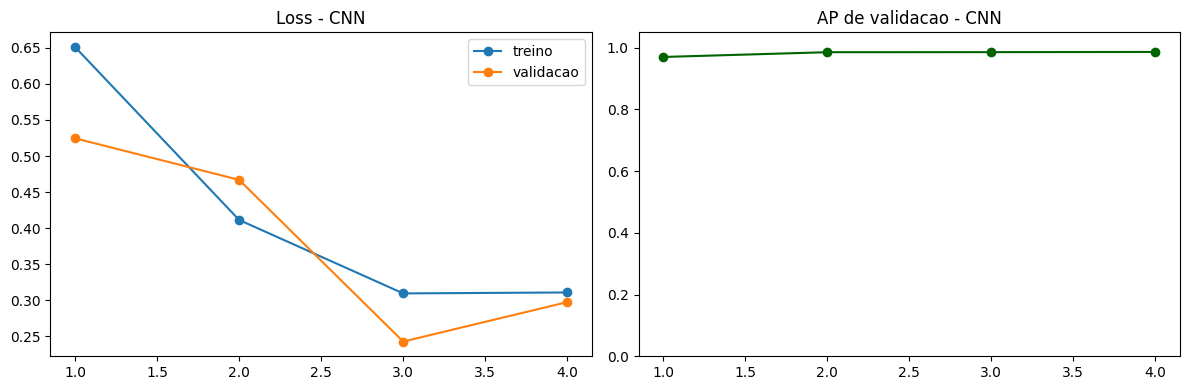

In [16]:
cnn_model = CNNClassifier()
cnn_model, cnn_history = train_model(
    cnn_model,
    cnn_train_loader,
    cnn_val_loader,
    epochs=4,
    lr=1e-3,
)

plot_history(cnn_history, "CNN")


In [17]:
cnn_test_loss, cnn_test_ap, cnn_y_true, cnn_y_prob = evaluate_model(
    cnn_model,
    cnn_test_loader,
    criterion,
)

print(f"CNN - test_loss = {cnn_test_loss:.4f}")
print(f"CNN - test_AP   = {cnn_test_ap:.4f}")


CNN - test_loss = 0.2873
CNN - test_AP   = 0.9917


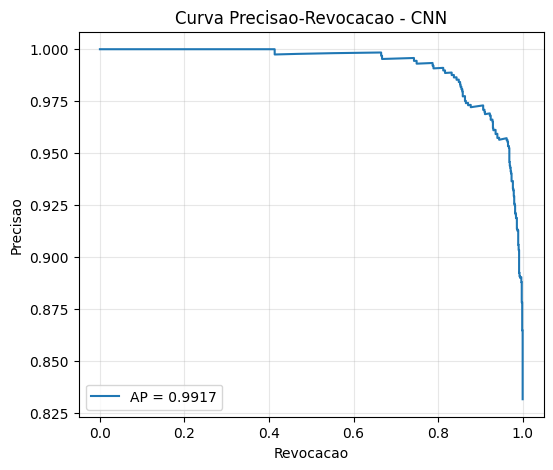

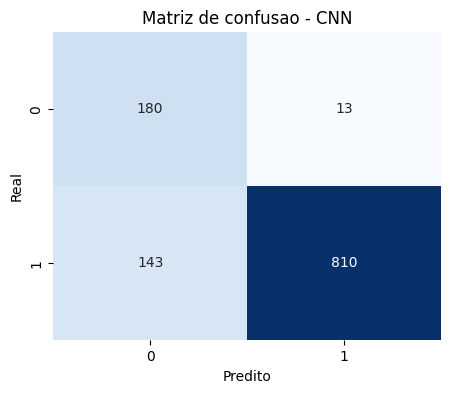

              precision    recall  f1-score   support

          MR     0.5573    0.9326    0.6977       193
          WF     0.9842    0.8499    0.9122       953

    accuracy                         0.8639      1146
   macro avg     0.7707    0.8913    0.8049      1146
weighted avg     0.9123    0.8639    0.8760      1146



In [18]:
plot_pr_curve(cnn_y_true, cnn_y_prob, "Curva Precisao-Revocacao - CNN")
show_confusion_matrix(cnn_y_true, cnn_y_prob, "Matriz de confusao - CNN")


## 9. Comparação dos resultados

O critério principal do projeto é a área sob a curva Precisão-Revocação.
Vamos comparar os dois modelos usando a métrica no conjunto de teste.


In [19]:
results = pd.DataFrame(
    [
        {
            "modelo": "MLP",
            "parametros": count_params(mlp_model),
            "test_loss": mlp_test_loss,
            "test_ap": mlp_test_ap,
        },
        {
            "modelo": "CNN",
            "parametros": count_params(cnn_model),
            "test_loss": cnn_test_loss,
            "test_ap": cnn_test_ap,
        },
    ]
)

results.sort_values("test_ap", ascending=False).reset_index(drop=True)


,modelo,parametros,test_loss,test_ap
0,MLP,803201,0.165714,0.995267
1,CNN,23649,0.287277,0.991725


## 10. Discussão

Pontos principais para discutir no relatório:

- O problema é relativamente separável, em parte porque os recortes das duas classes possuem escalas e aparências distintas.
- Mesmo um MLP pode atingir desempenho alto, o que sugere que tamanho e contraste já fornecem pistas fortes.
- Apesar disso, a **CNN continua sendo a escolha metodologicamente mais adequada** porque:
  - preserva a estrutura espacial;
  - usa muito menos parâmetros;
  - generaliza melhor para tarefas visuais em cenários mais difíceis;
  - está alinhada ao foco do projeto, que pede exploração de arquiteturas convolucionais.
- O uso de `WeightedRandomSampler` foi importante para mitigar o desbalanceamento entre `WF` e `MR`.


## 11. Resultados locais de referência

Em uma execução local de teste, foram obtidos os seguintes valores:

- **MLP**: `test_AP = 0.9949`
- **CNN**: `test_AP = 0.9927`

Esses números podem variar um pouco entre execuções, mas mostram que:

1. o pipeline está funcionando corretamente;
2. a tarefa é bem separável;
3. a CNN entrega desempenho competitivo com muito menos parâmetros.


## 12. Conclusão

A solução atendeu ao enunciado:

- os dados foram montados a partir das pastas `WF` e `MR`;
- foi feita divisão treino/validação/teste;
- houve pré-processamento com redimensionamento e aumento de dados;
- foram treinados modelos neurais artificiais;
- a avaliação foi feita com **Precisão-Revocação / Average Precision**.

Como encaminhamento futuro, seria interessante:

- testar transferência de aprendizado com `ResNet18` ou `MobileNetV3`;
- usar validação cruzada estratificada;
- investigar erros com análise visual dos falsos positivos e falsos negativos.
